# **Importing Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# **Data Preperation**

In [2]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:03<00:00, 52.4MB/s]


# **Model Setup**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torchvision.models.mobilenet_v2(weights=torchvision.models.MobileNet_V2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 31.0MB/s]


In [4]:
model.classifier[1] = nn.Linear(1280, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# **Training \& Evaluation**

In [5]:
num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Avg Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/5] - Avg Loss: 0.9361
Epoch [2/5] - Avg Loss: 0.7680
Epoch [3/5] - Avg Loss: 0.7430
Epoch [4/5] - Avg Loss: 0.7320
Epoch [5/5] - Avg Loss: 0.7244


In [6]:
correct = 0
total = 0
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nOverall Test Accuracy: {100 * correct / total:.2f}%\n")


Overall Test Accuracy: 77.72%



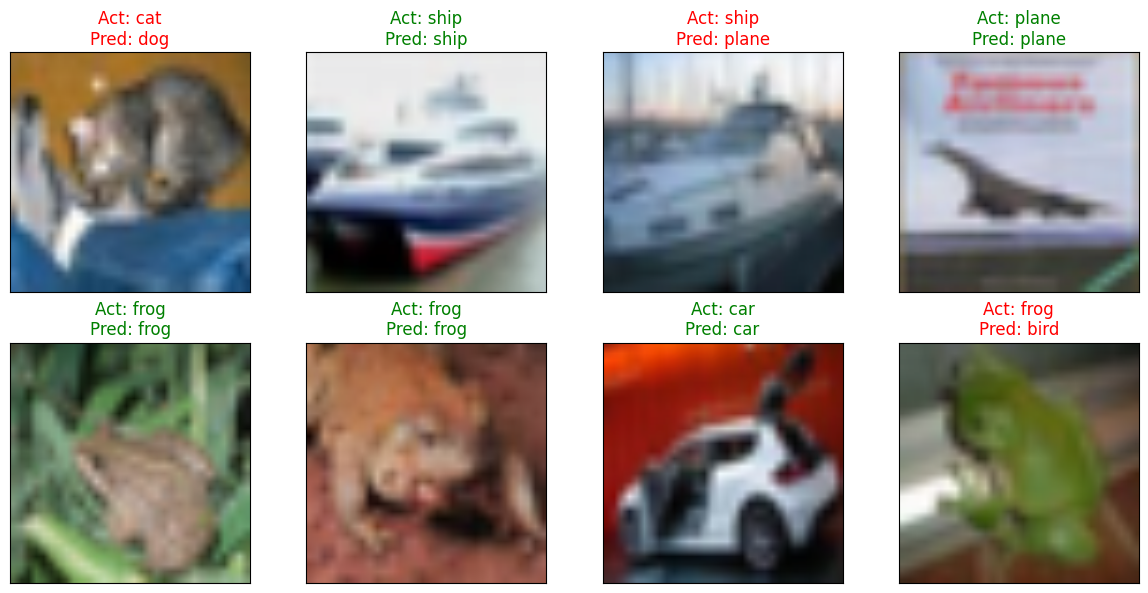

In [7]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

images_dev = images.to(device)
outputs = model(images_dev)
_, predicted = torch.max(outputs, 1)

fig = plt.figure(figsize=(12, 6))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(8):
    ax = fig.add_subplot(2, 4, i+1, xticks=[], yticks=[])

    img = images[i].numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

    act_label = classes[labels[i]]
    pred_label = classes[predicted[i].item()]
    color = "green" if act_label == pred_label else "red"
    ax.set_title(f"Act: {act_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()